In [165]:

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.io as sio
from scipy.linalg import eigh
from matplotlib.image import imread
import pandas as pd
from sklearn.decomposition import PCA
from matplotlib.ticker import MaxNLocator
from scipy.signal import lfilter

import os



AVIRIS is a Earth Remote Sensing instrument. It is an optical sensor that delivers calibrated images of the upwelling spectral radiance in 224 contiguous spectral channels (bands) with wavelengths from 400 to 2500 nanometers. 

AVIRIS has been flown on four aircraft platforms: NASA's ER-2 jet, Twin Otter International's turboprop, Scaled Composites' Proteus, and NASA's WB-57. AVIRIS has flown North America, Europe, portions of South America, and Argentina.
* The ER-2 flies at approximately 20 km above sea level, at about 730 km/hr. 
* The Twin Otter aircraft flies at 4km above ground level at 130km/hr.

The main objective of the AVIRIS project is to identify, measure, and monitor constituents of the Earth's surface and atmosphere based on molecular absorption and particle scattering signatures. Research with AVIRIS data is predominantly focused on understanding processes related to the global environment and climate change.

In [166]:
rawData = sio.loadmat('Indian_pines_corrected.mat')
print(rawData.keys())

dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_corrected'])


In [167]:
print(rawData['__header__'])
print(rawData['__version__'])
print(rawData['__globals__'])

b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Fri May 20 18:47:44 2011'
1.0
[]


The AVIRIS sensor collects data that can be used for characterization of the Earth's surface and atmosphere from geometrically coherent spectroradiometric measurements. 

This data can be applied to studies in the fields of oceanography, environmental science, snow hydrology, geology, volcanology, soil and land management, atmospheric and aerosol studies, agriculture, and limnology. 

Applications under development include the assessment and monitoring of environmental hazards such as toxic waste, oil spills, and land/air/water pollution.

With proper calibration and correction for atmospheric effects, the measurements can be converted to ground reflectance data which can then be used for quantitative characterization of surface features.

In [168]:
inputData = rawData['indian_pines_corrected']
print(inputData.shape)

(145, 145, 200)


In [169]:
flattenedData = inputData.reshape(-1, inputData.shape[2])
print(flattenedData.shape) # (145 x 145 rows flattened from image, 200 bands)

(21025, 200)


## PCA using sklearn library

In [170]:
nPCs = 20
nPCArray = np.linspace(0,nPCs, nPCs)
pca = PCA(n_components=nPCs)
pca.fit(flattenedData)
Xnew = pca.fit_transform(flattenedData)
Xnew = np.reshape(Xnew, (145, 145, nPCs))

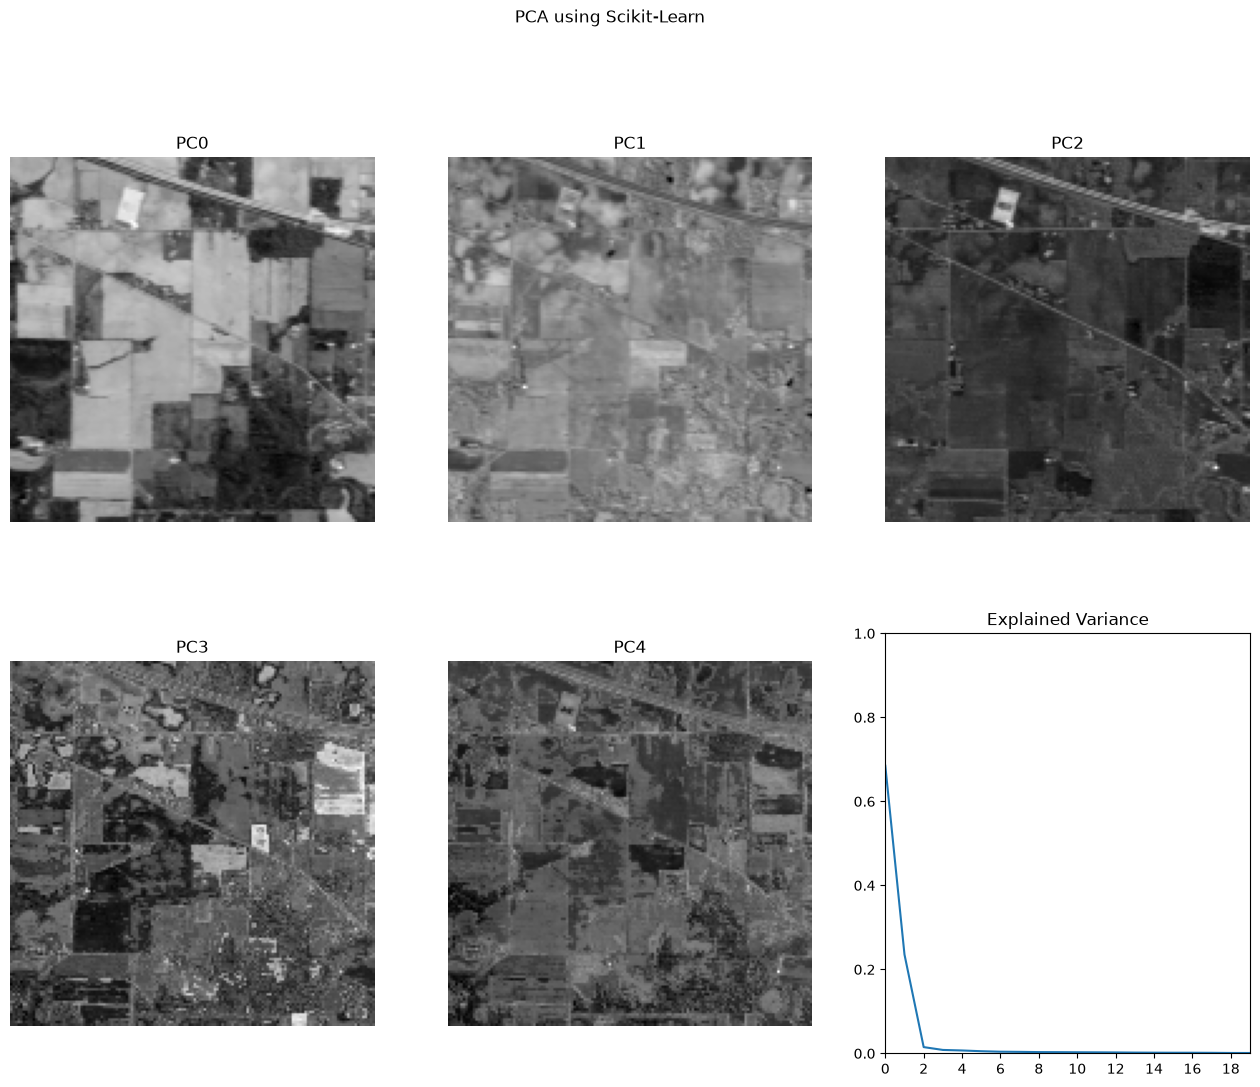

In [171]:
cmapName = 'grey'
plt.figure(figsize=(16, 12))
plt.suptitle("PCA using Scikit-Learn")

plt.subplot(231)
plt.imshow(Xnew[:,:,0],cmap=cmapName)
plt.title('PC0')
plt.axis('off')
plt.subplot(232)
plt.imshow(Xnew[:,:,1],cmap=cmapName)
plt.title('PC1')
plt.axis('off')
plt.subplot(233)
plt.imshow(Xnew[:,:,2],cmap=cmapName)
plt.title('PC2')
plt.axis('off')
plt.subplot(234)
plt.imshow(Xnew[:,:,3],cmap=cmapName)
plt.title('PC3')
plt.axis('off')
plt.subplot(235)
plt.imshow(Xnew[:,:,4],cmap=cmapName)
plt.title('PC4')
plt.axis('off')

plt.subplot(236)
plt.plot(pca.explained_variance_ratio_)
plt.title('Explained Variance')
plt.xlim(0,nPCs-1)
plt.ylim(0,1)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

## PCA and MNF from using Eigenvalue Decomposition

In [172]:
def PCAImgfunc(inputData):

    flattenedData = inputData.reshape(-1, inputData.shape[2])

    centeredData = flattenedData - np.mean(flattenedData, axis=0)[np.newaxis,:]

    covarianceMatrix = np.cov(centeredData, rowvar=False)

    eigValues, eigVectors = np.linalg.eig(covarianceMatrix)

    # EigenDecomp
    sortedIndices = np.argsort(eigValues)[::-1] #np.argsort does ascending by default, [::-1] reverses it. Largest to smallest eigenvalues ordering
    sortedEigValues = eigValues[sortedIndices] #Variance
    sortedEigVectors = eigVectors[:, sortedIndices] #Principal Components

    nPC_Eigenvectors = sortedEigVectors[:,:] #The first nPCs Principal Components from the sorted Eigenvectors
    print(nPC_Eigenvectors.shape)

    eigVecTest = np.dot(nPC_Eigenvectors[:,0], nPC_Eigenvectors[:,0]) # To confirm u^T u (i.e. dot product = 1)
    print(rf"Dot Product of 2 eigVectors must be 1. Checking: {eigVecTest}. If ~1 we good.")


    PC2Data = np.dot(centeredData, nPC_Eigenvectors)
    PC2Img = np.real(PC2Data.reshape(inputData.shape[0], inputData.shape[1],200))

    sumEigVals = np.sum(sortedEigValues)
    varianceRatio = sortedEigValues/sumEigVals

    print("Original data shape:", inputData.shape)
    print("Reduced data shape:", PC2Img.shape)
    print("\n")

    return PC2Img, varianceRatio


def MNF(inputData):

    # Finding the noise in data assuming noise is unknown
    delta1 = inputData[:-1,:,:] - inputData[1:,:,:]# (col 0 to n-1) - (col 1 to n) i.e. VERTICALLY: pixel 0 - pixel1 ideally must be 0 because the pixeds are looking at almost the same thing so residual must be 0. If residual >0, then consider that noise
    delta2 = inputData[:,:-1,:] - inputData[:,1:,:]# (col 0 to n-1) - (col 1 to n) i.e. HORIZONTALLY: pixel 0 - pixel1 ideally must be 0 because the pixeds are looking at almost the same thing so residual must be 0. If residual >0, then consider that noise
    deltaXY = [delta1.reshape(-1,inputData.shape[2]), delta2.reshape(-1,inputData.shape[2])]
    approximatedNoise = np.vstack(deltaXY)
    noiseCovarianceMatrix = 0.5 * np.cov(approximatedNoise, rowvar=False) # Cov(px1 - px2) = 2 Cov(px)

    flattenedData = inputData.reshape(-1, inputData.shape[2])
    centeredData = flattenedData - np.mean(flattenedData, axis=0)[np.newaxis,:]
    rawCovarianceMatrix = np.cov(centeredData, rowvar=False)

    #EigenDecomp
    # S u1 = \lambda1 Sn u1
    #rawCov * eigVec = eigVal * noiseCov * eigVec
    eigValues, eigVectors = eigh(rawCovarianceMatrix, noiseCovarianceMatrix)

    # maximise SNR where SNR = E(Xs^2)/E(Xn^2) ~ var(Xs)/var(Xn)
    idx = np.argsort(eigValues)[::-1]
    mnfEigVals = eigValues[idx]; SNR = mnfEigVals - 1 #NF is related to SNRs --> must maximise
    mnfEigVecs = eigVectors[:, idx]

    flattenedData = centeredData @ mnfEigVecs # X Data vector, u eigenVector
    MNFtoImg = flattenedData.reshape(inputData.shape)

    print("Original data shape:", inputData.shape)
    print("Reduced data shape:", MNFtoImg.shape)

    return MNFtoImg, SNR


def MNFknown(inputData, noiseData):

    # Noise is known
    flattenedNoise = noiseData.reshape(-1, noiseData.shape[2])
    centeredNoise = flattenedNoise - np.mean(flattenedNoise, axis=0)[np.newaxis,:]
    noiseCovarianceMatrix = np.cov(centeredNoise, rowvar=False)

    flattenedData = inputData.reshape(-1, inputData.shape[2])
    centeredData = flattenedData - np.mean(flattenedData, axis=0)[np.newaxis,:]
    rawCovarianceMatrix = np.cov(centeredData, rowvar=False)

    #EigenDecomp
    # S u1 = \lambda1 Sn u1
    #rawCov * eigVec = eigVal * noiseCov * eigVec
    eigValues, eigVectors = eigh(rawCovarianceMatrix, noiseCovarianceMatrix)

    # maximise SNR where SNR = E(Xs^2)/E(Xn^2) ~ var(Xs)/var(Xn)
    idx = np.argsort(eigValues)[::-1]
    mnfEigVals = eigValues[idx]; SNR = mnfEigVals - 1 #NF is related to SNRs --> must maximise
    mnfEigVecs = eigVectors[:, idx]

    flattenedData = centeredData @ mnfEigVecs # X Data vector, u eigenVector
    MNFtoImg = flattenedData.reshape(inputData.shape)

    print("Original data shape:", inputData.shape)
    print("Reduced data shape:", MNFtoImg.shape)

    return MNFtoImg, SNR


def plotPCAImg(PC2Img, varRatio, title):
    PCidx = np.round(np.linspace(1, 50, 7) - 1, 5).astype(int)

    cmapName = 'grey'
    plt.figure(figsize=(16, 12))
    plt.suptitle(title)

    plt.subplot(231)
    plt.imshow(PC2Img[:,:,PCidx[0]],cmap=cmapName)
    plt.title(rf'PC{PCidx[0]}')
    plt.axis('off')

    plt.subplot(232)
    plt.imshow(PC2Img[:,:,PCidx[1]],cmap=cmapName)
    plt.title(rf'PC{PCidx[1]}')
    plt.axis('off')

    plt.subplot(233)
    plt.imshow(PC2Img[:,:,PCidx[2]],cmap=cmapName)
    plt.title(rf'PC{PCidx[2]}')
    plt.axis('off')

    plt.subplot(234)
    plt.imshow(PC2Img[:,:,PCidx[3]],cmap=cmapName)
    plt.title(rf'PC{PCidx[3]}')
    plt.axis('off')

    plt.subplot(235)
    plt.imshow(PC2Img[:,:,PCidx[4]],cmap=cmapName)
    plt.title(rf'PC{PCidx[4]}')
    plt.axis('off')
    
    plt.subplot(236)
    plt.plot(np.real(varRatio[:nPCs]))
    plt.title('Explained Variance')
    plt.xlim(0,nPCs-1)
    plt.ylim(0,1)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.show()
    

    return 0


def plotMNFImg(MNFtoImg, SNR, title):

    PCidx = np.round(np.linspace(1, 50, 7) - 1, 5).astype(int)

    cmapName = 'grey'
    plt.figure(figsize=(16, 12))
    plt.suptitle(title)

    plt.subplot(231)
    plt.imshow(MNFtoImg[:,:,PCidx[0]],cmap=cmapName)
    plt.title(rf'MNF{PCidx[0]}')
    plt.axis('off')

    plt.subplot(232)
    plt.imshow(MNFtoImg[:,:,PCidx[1]],cmap=cmapName)
    plt.title(rf'MNF{PCidx[1]}')
    plt.axis('off')

    plt.subplot(233)
    plt.imshow(MNFtoImg[:,:,PCidx[2]],cmap=cmapName)
    plt.title(rf'MNF{PCidx[2]}')
    plt.axis('off')

    plt.subplot(234)
    plt.imshow(MNFtoImg[:,:,PCidx[3]],cmap=cmapName)
    plt.title(rf'MNF{PCidx[3]}')
    plt.axis('off')

    plt.subplot(235)
    plt.imshow(MNFtoImg[:,:,PCidx[4]],cmap=cmapName)
    plt.title(rf'MNF{PCidx[4]}')
    plt.axis('off')

    plt.subplot(236)
    plt.plot(np.real(SNR[:20]))
    plt.title('SNR')
    plt.xlim(0,nPCs-1)
    #plt.ylim(0,1)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.show()

    return 0




(200, 200)
Dot Product of 2 eigVectors must be 1. Checking: (1.0000000000000004+0j). If ~1 we good.
Original data shape: (145, 145, 200)
Reduced data shape: (145, 145, 200)




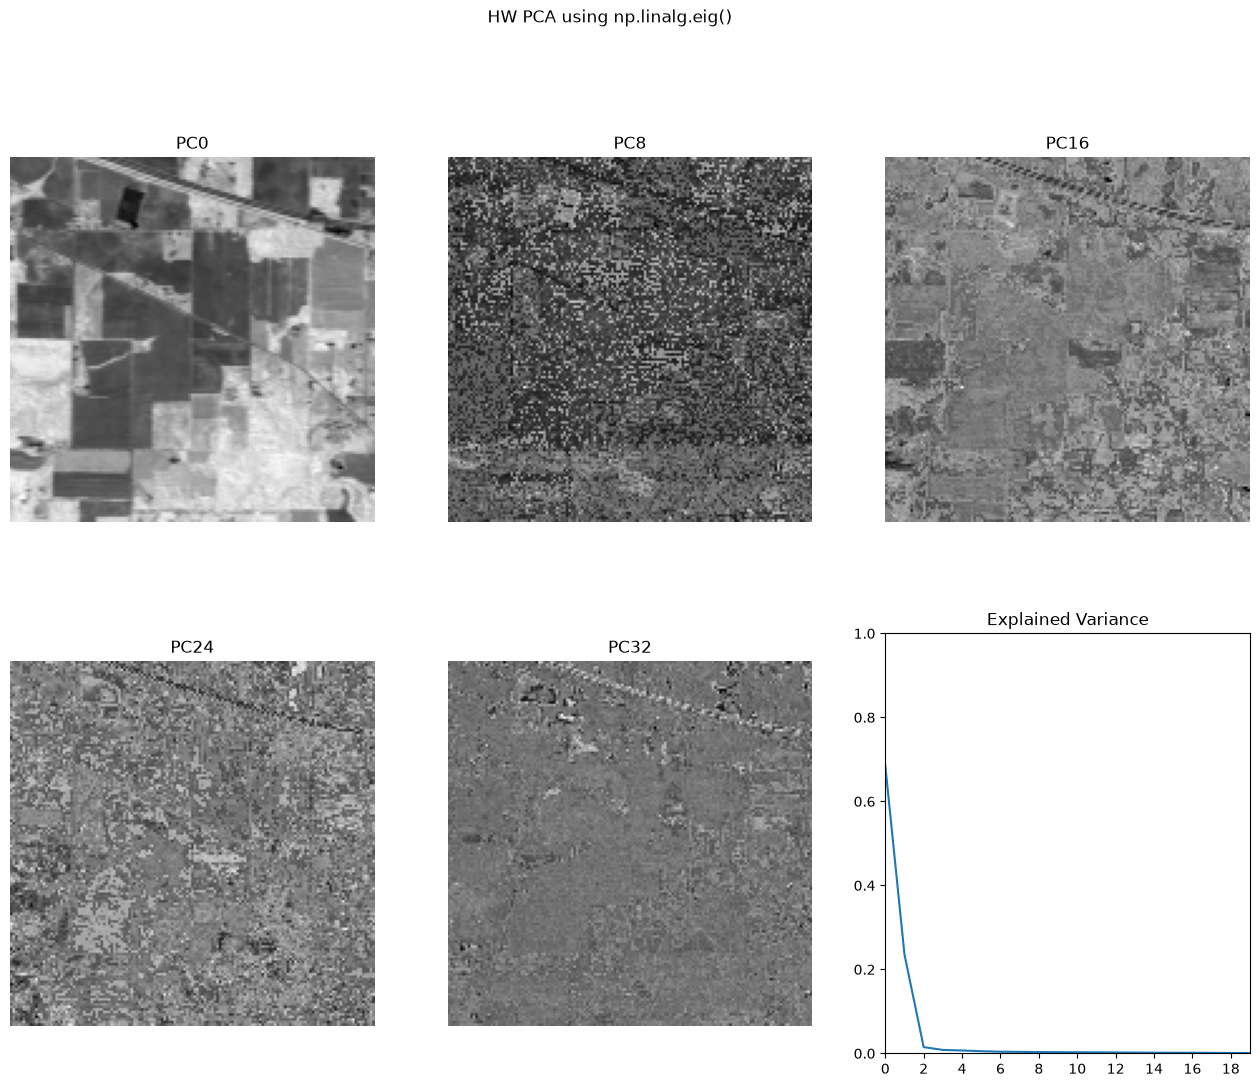

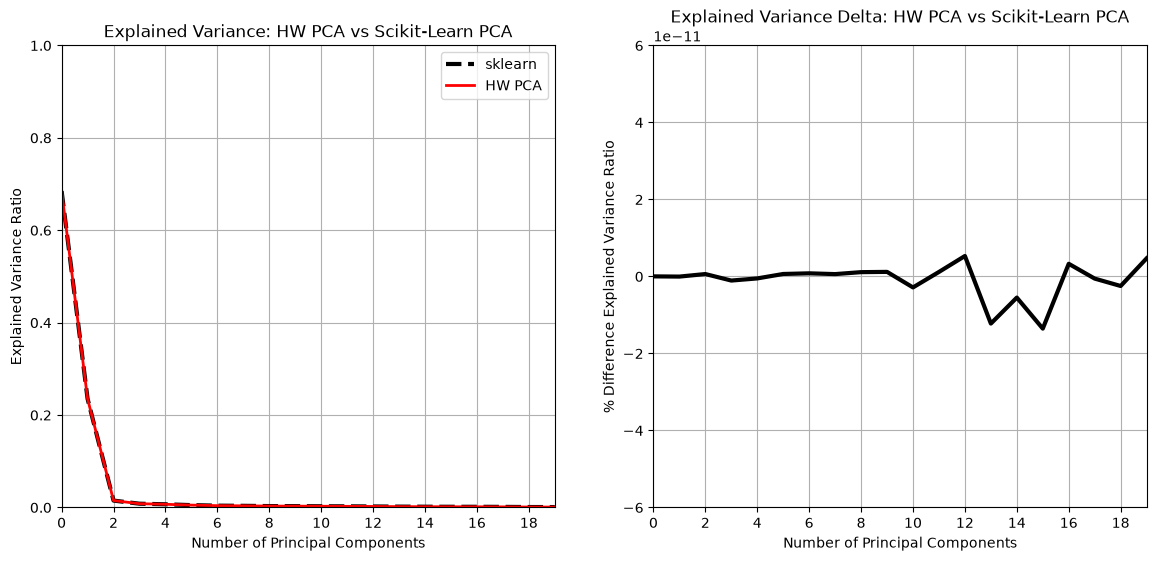

In [173]:
PCImg, varRatio = PCAImgfunc(inputData)
plotPCAImg(PCImg, varRatio, "HW PCA using np.linalg.eig()")

plt.figure(figsize=(14,6))
plt.subplot(121)
plt.plot(pca.explained_variance_ratio_, label="sklearn", linewidth=3, color='k', linestyle='--')
plt.plot(np.real(varRatio[:nPCs]), label="HW PCA", linewidth=2, color='r', linestyle='-')
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.xlim(0,nPCs-1)
plt.ylim(0,1)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()
plt.grid(True)
plt.title('Explained Variance: HW PCA vs Scikit-Learn PCA')

plt.subplot(122)
plt.plot((np.real(varRatio[:nPCs]) - pca.explained_variance_ratio_)*100/pca.explained_variance_ratio_, linewidth=3, color='k', linestyle='-')
plt.xlabel("Number of Principal Components")
plt.ylabel("% Difference Explained Variance Ratio")
plt.xlim(0,nPCs-1)
plt.ylim(-6e-11,6e-11)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(True)
plt.title('Explained Variance Delta: HW PCA vs Scikit-Learn PCA')

plt.show()




In [174]:
print(np.sum(varRatio[0:4]))


(0.9434306640418073+0j)


# Making Noise

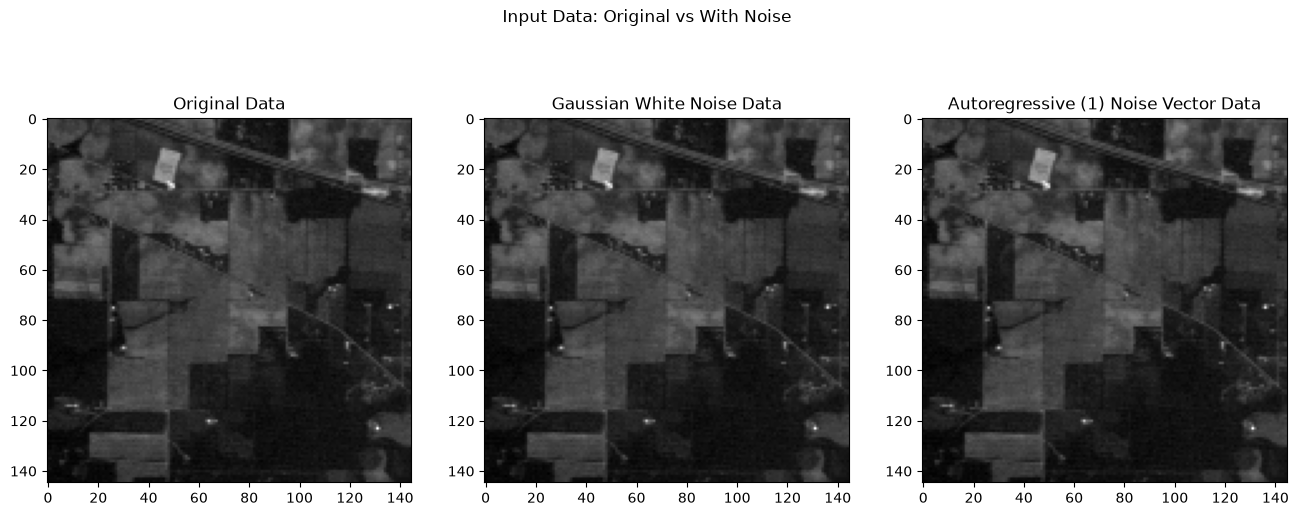

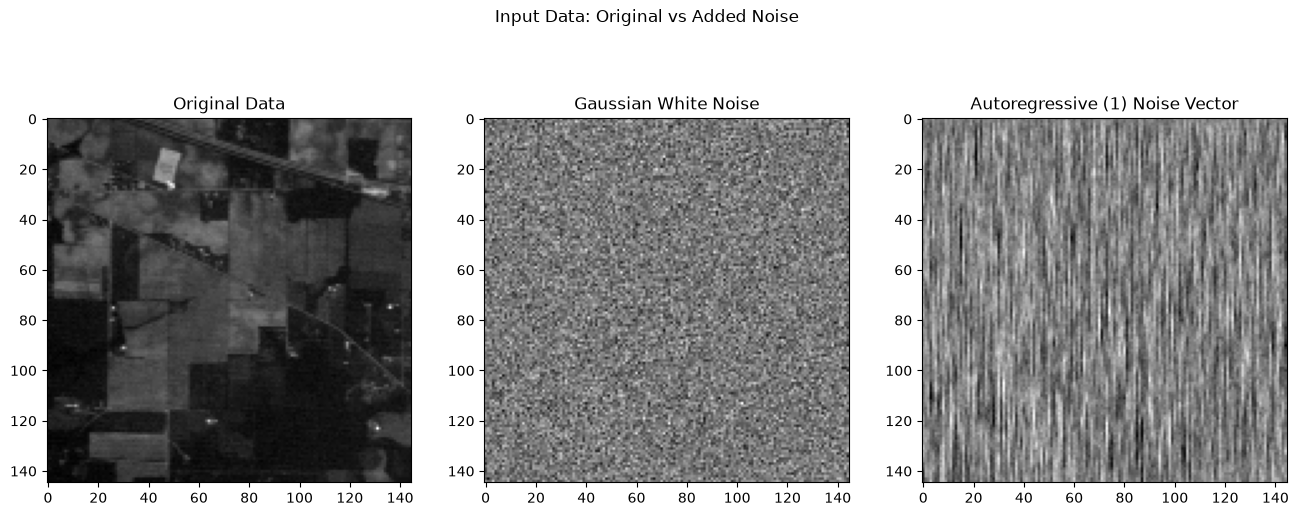

In [175]:
gaussianWhiteNoise = np.random.randn(*inputData.shape) * 1

b, a = [1], [1, -0.9]
flattenedGWN = gaussianWhiteNoise.reshape(inputData.shape[0], -1)
flattenedFilteredNoise = lfilter(b, a, flattenedGWN, axis=0)
autoregressive1NoiseVector = flattenedFilteredNoise.reshape(*inputData.shape)

inputDataGWN = inputData + gaussianWhiteNoise
inputDataANV = inputData + autoregressive1NoiseVector


channelSlice = 5
plt.figure(figsize=(16,6))
plt.suptitle("Input Data: Original vs With Noise")

plt.subplot(131)
plt.imshow(inputData[:,:,channelSlice], cmap='grey')
plt.title('Original Data')

plt.subplot(132)
plt.imshow(inputDataGWN[:,:,channelSlice], cmap='grey')
plt.title('Gaussian White Noise Data')

plt.subplot(133)
plt.imshow(inputDataANV[:,:,channelSlice], cmap='grey')
plt.title('Autoregressive (1) Noise Vector Data')

plt.show()


channelSlice = 5
plt.figure(figsize=(16,6))
plt.suptitle("Input Data: Original vs Added Noise")
plt.subplot(131)
plt.imshow(inputData[:,:,channelSlice], cmap='grey')
plt.title('Original Data')

plt.subplot(132)
plt.imshow(gaussianWhiteNoise[:,:,channelSlice], cmap='grey')
plt.title('Gaussian White Noise')

plt.subplot(133)
plt.imshow(autoregressive1NoiseVector[:,:,channelSlice], cmap='grey')
plt.title('Autoregressive (1) Noise Vector')

plt.show()


(200, 200)
Dot Product of 2 eigVectors must be 1. Checking: (0.9999999999999998+0j). If ~1 we good.
Original data shape: (145, 145, 200)
Reduced data shape: (145, 145, 200)


(200, 200)
Dot Product of 2 eigVectors must be 1. Checking: (0.9999999999999999+0j). If ~1 we good.
Original data shape: (145, 145, 200)
Reduced data shape: (145, 145, 200)




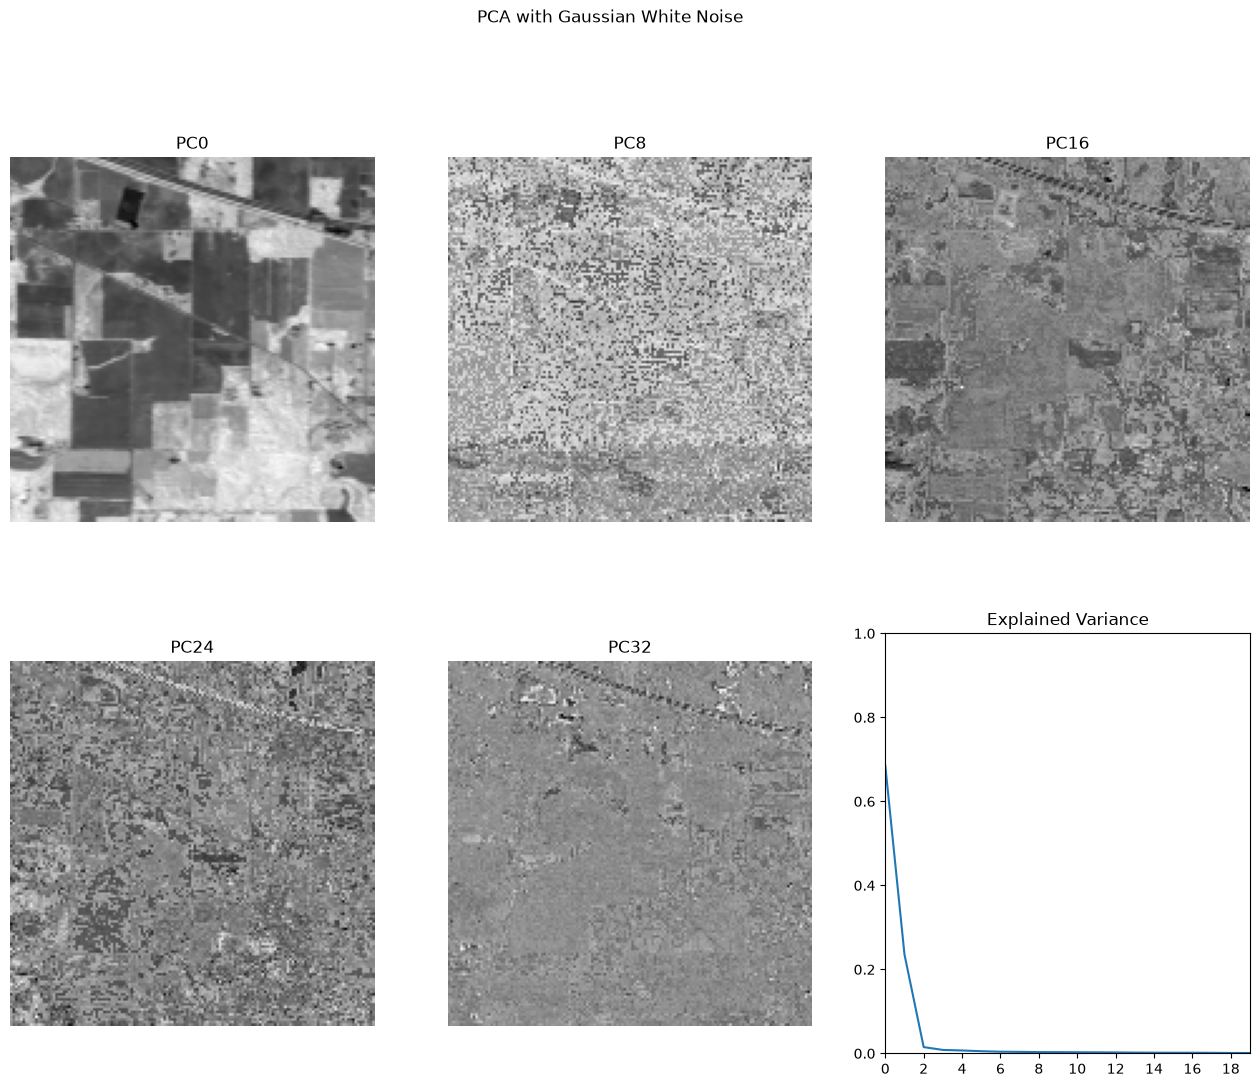

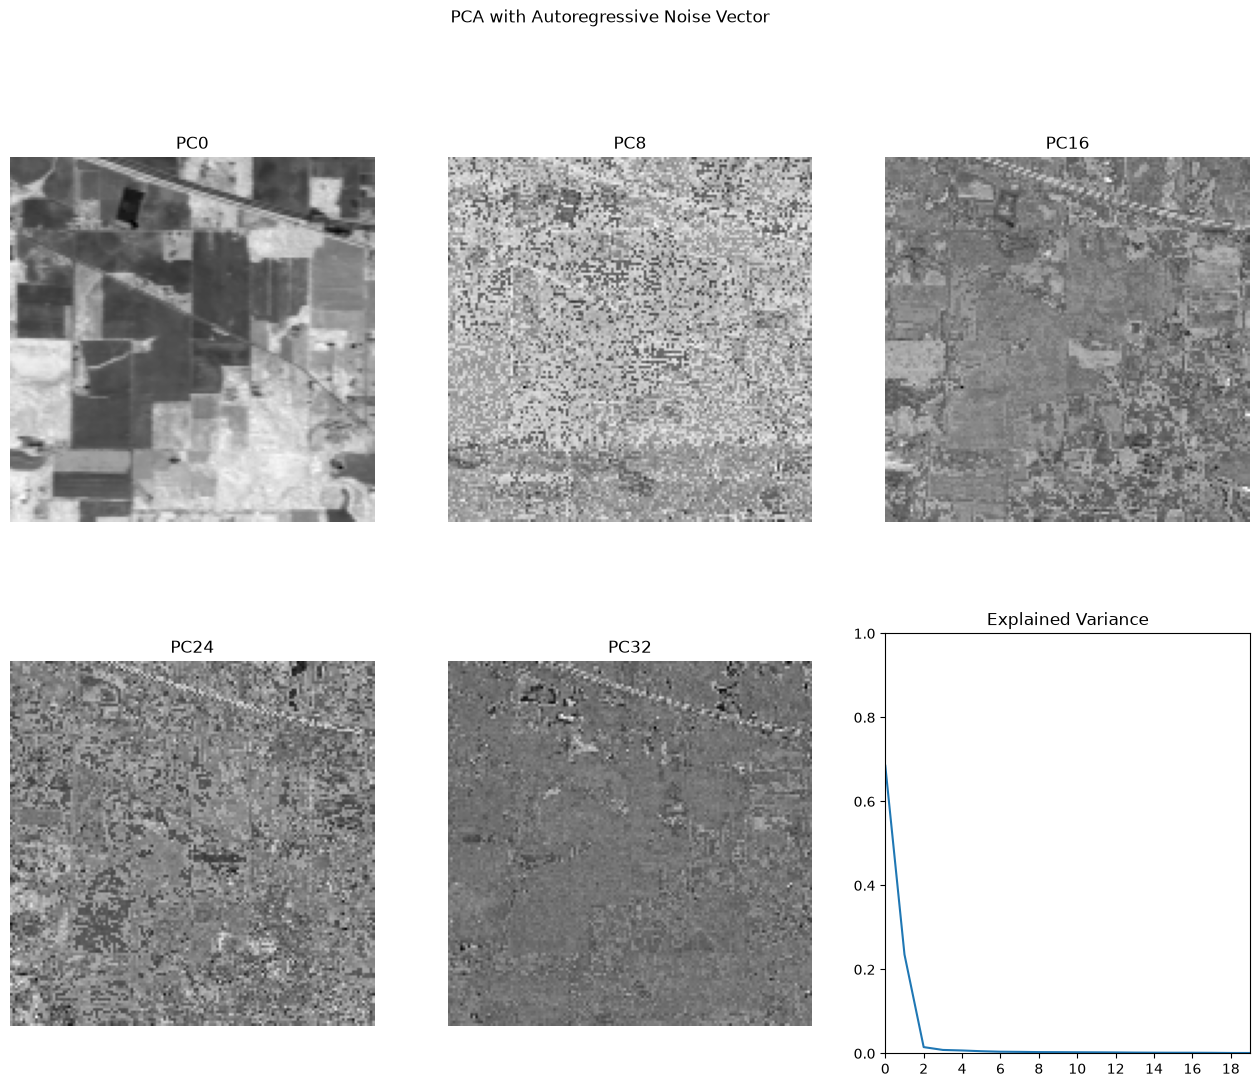

0

In [176]:
PCImgGWN, varRatioGWN = PCAImgfunc(inputDataGWN)
PCImgANV, varRatioANV = PCAImgfunc(inputDataANV)

plotPCAImg(PCImgGWN, varRatioGWN, "PCA with Gaussian White Noise")
plotPCAImg(PCImgANV, varRatioANV, "PCA with Autoregressive Noise Vector")



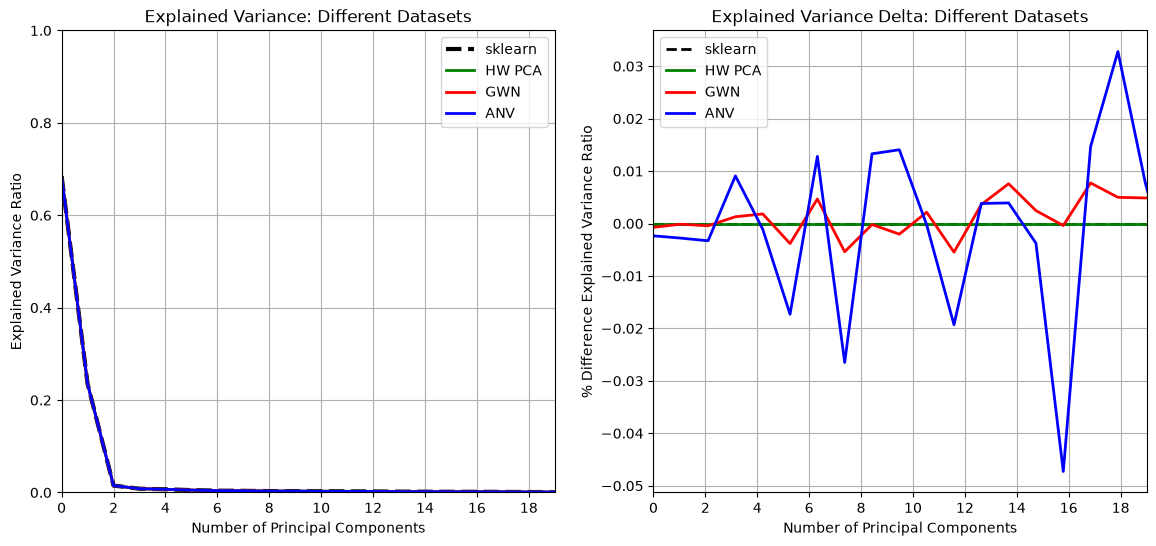

In [177]:
plt.figure(figsize=(14,6))

plt.subplot(121)
plt.plot(pca.explained_variance_ratio_, label="sklearn", linewidth=3, color='k', linestyle='--')
plt.plot(np.real(varRatio[:nPCs]), label="HW PCA", linewidth=2, color='g', linestyle='-')
plt.plot(np.real(varRatioGWN[:nPCs]), label="GWN", linewidth=2, color='r', linestyle='-')
plt.plot(np.real(varRatioANV[:nPCs]), label="ANV", linewidth=2, color='b', linestyle='-')

plt.legend()
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.xlim(0,nPCs-1)
plt.ylim(0,1)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(True)
plt.title('Explained Variance: Different Datasets')


plt.subplot(122)
plt.plot(nPCArray, (pca.explained_variance_ratio_ - pca.explained_variance_ratio_)*100/pca.explained_variance_ratio_, linewidth=2, color='k', linestyle='--', label="sklearn")
plt.plot(nPCArray, (np.real(varRatio[:nPCs]) - pca.explained_variance_ratio_)*100/pca.explained_variance_ratio_, linewidth=2, color='g', linestyle='-', label="HW PCA")
plt.plot(nPCArray, (np.real(varRatioGWN[:nPCs]) - pca.explained_variance_ratio_)*100/pca.explained_variance_ratio_, linewidth=2, color='r', linestyle='-', label="GWN")
plt.plot(nPCArray, (np.real(varRatioANV[:nPCs]) - pca.explained_variance_ratio_)*100/pca.explained_variance_ratio_, linewidth=2, color='b', linestyle='-', label="ANV")

plt.xlabel("Number of Principal Components")
plt.ylabel("% Difference Explained Variance Ratio")
plt.xlim(0,nPCs-1)
#plt.ylim(-6e-11,6e-11)
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Explained Variance Delta: Different Datasets')

plt.show()

Original data shape: (145, 145, 200)
Reduced data shape: (145, 145, 200)


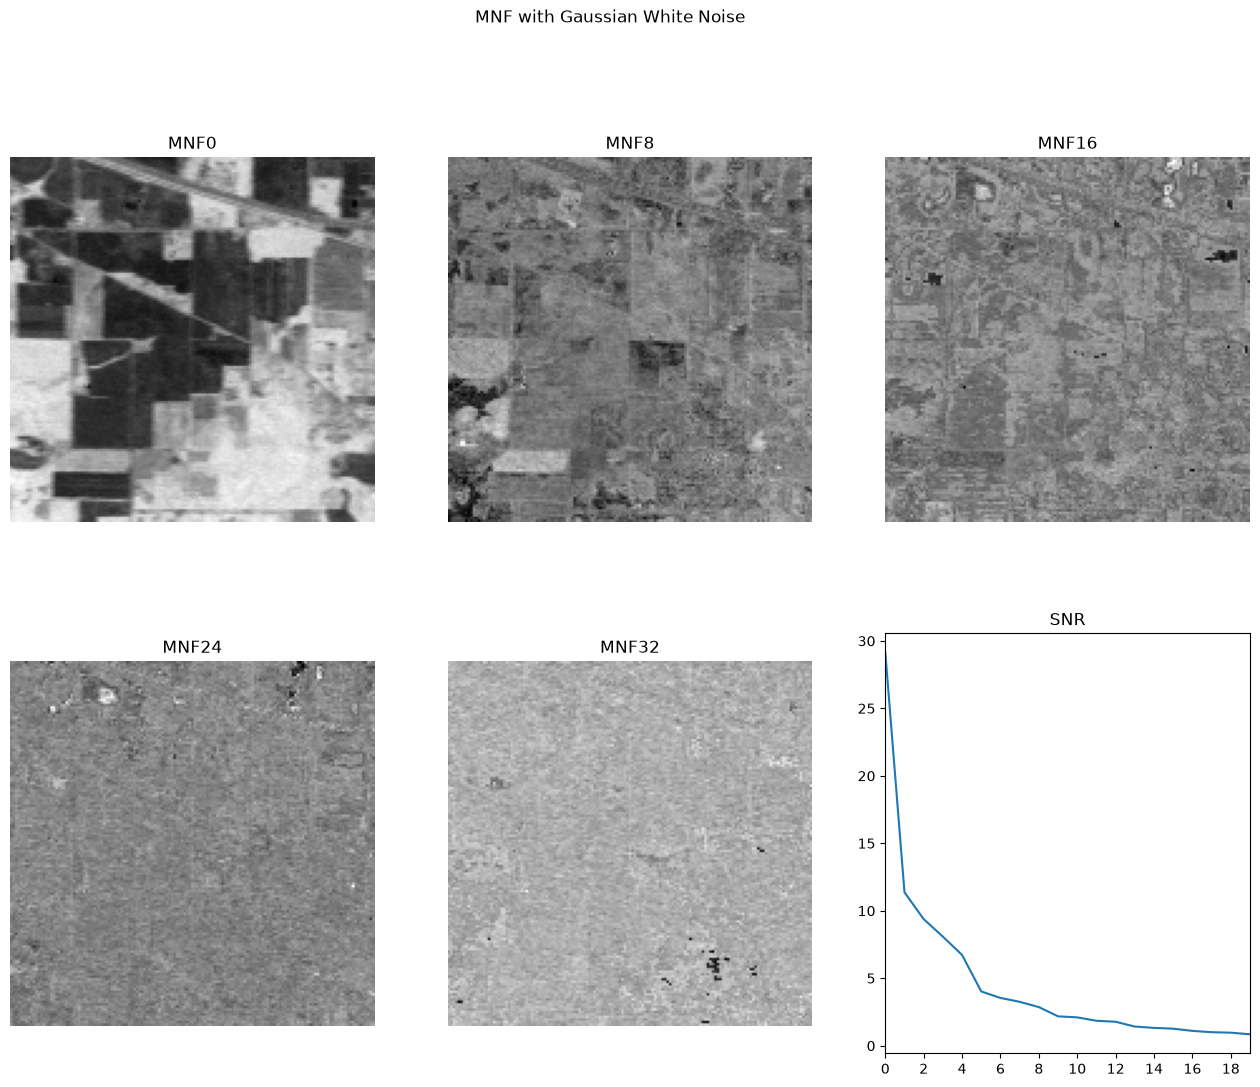

Original data shape: (145, 145, 200)
Reduced data shape: (145, 145, 200)


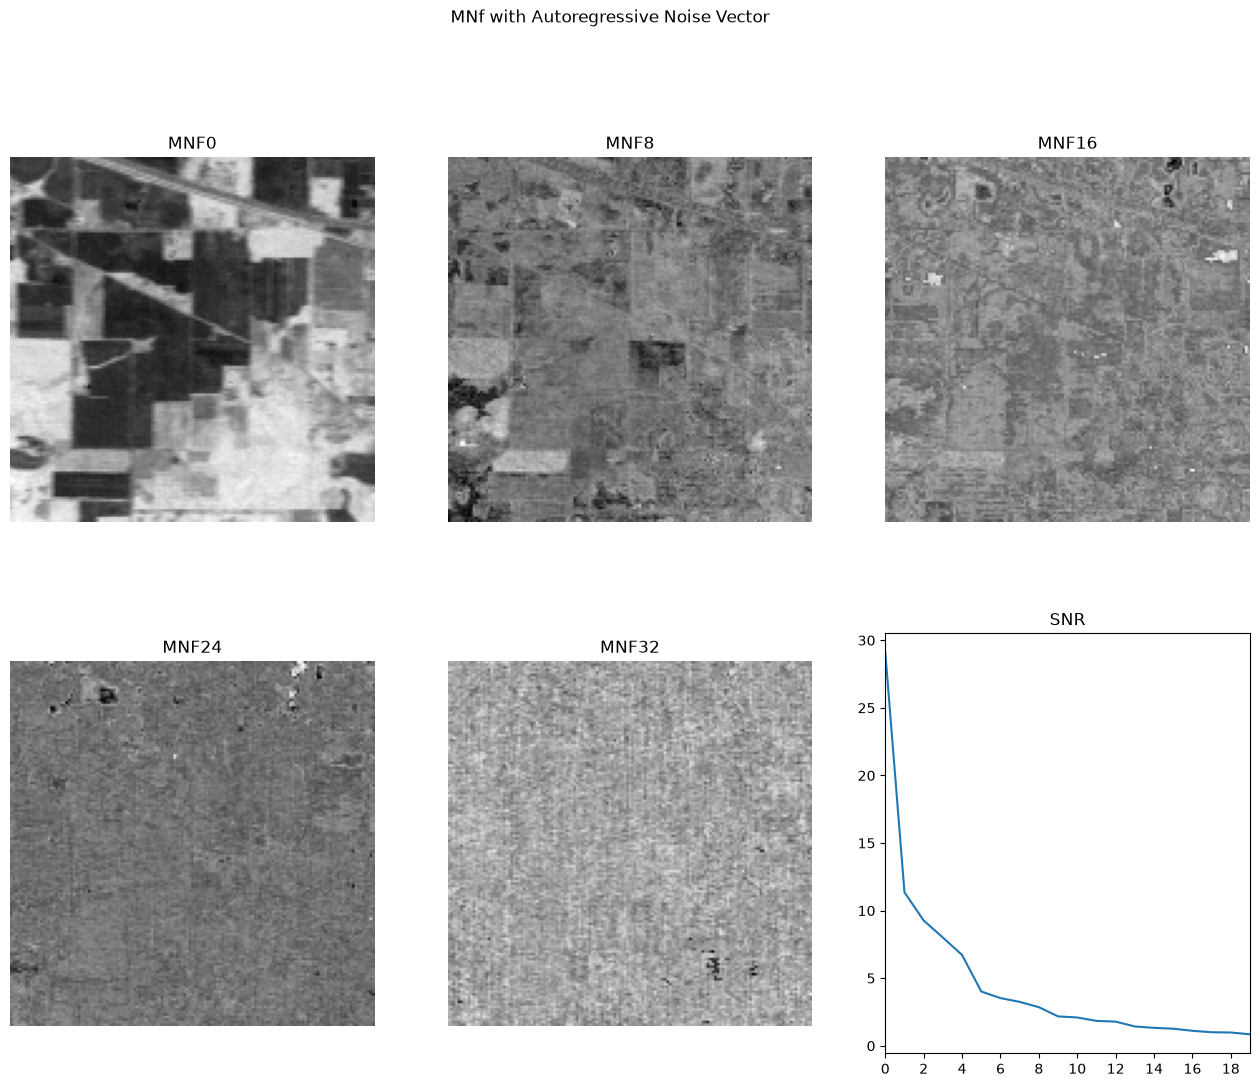

0

In [181]:
mnfGWN, snrGWN = MNF(inputDataGWN)
plotMNFImg(mnfGWN, snrGWN, "MNF with Gaussian White Noise")

mnfANV, snrANV = MNF(inputDataANV)
plotMNFImg(mnfANV, snrANV, "MNf with Autoregressive Noise Vector")



Original data shape: (145, 145, 200)
Reduced data shape: (145, 145, 200)


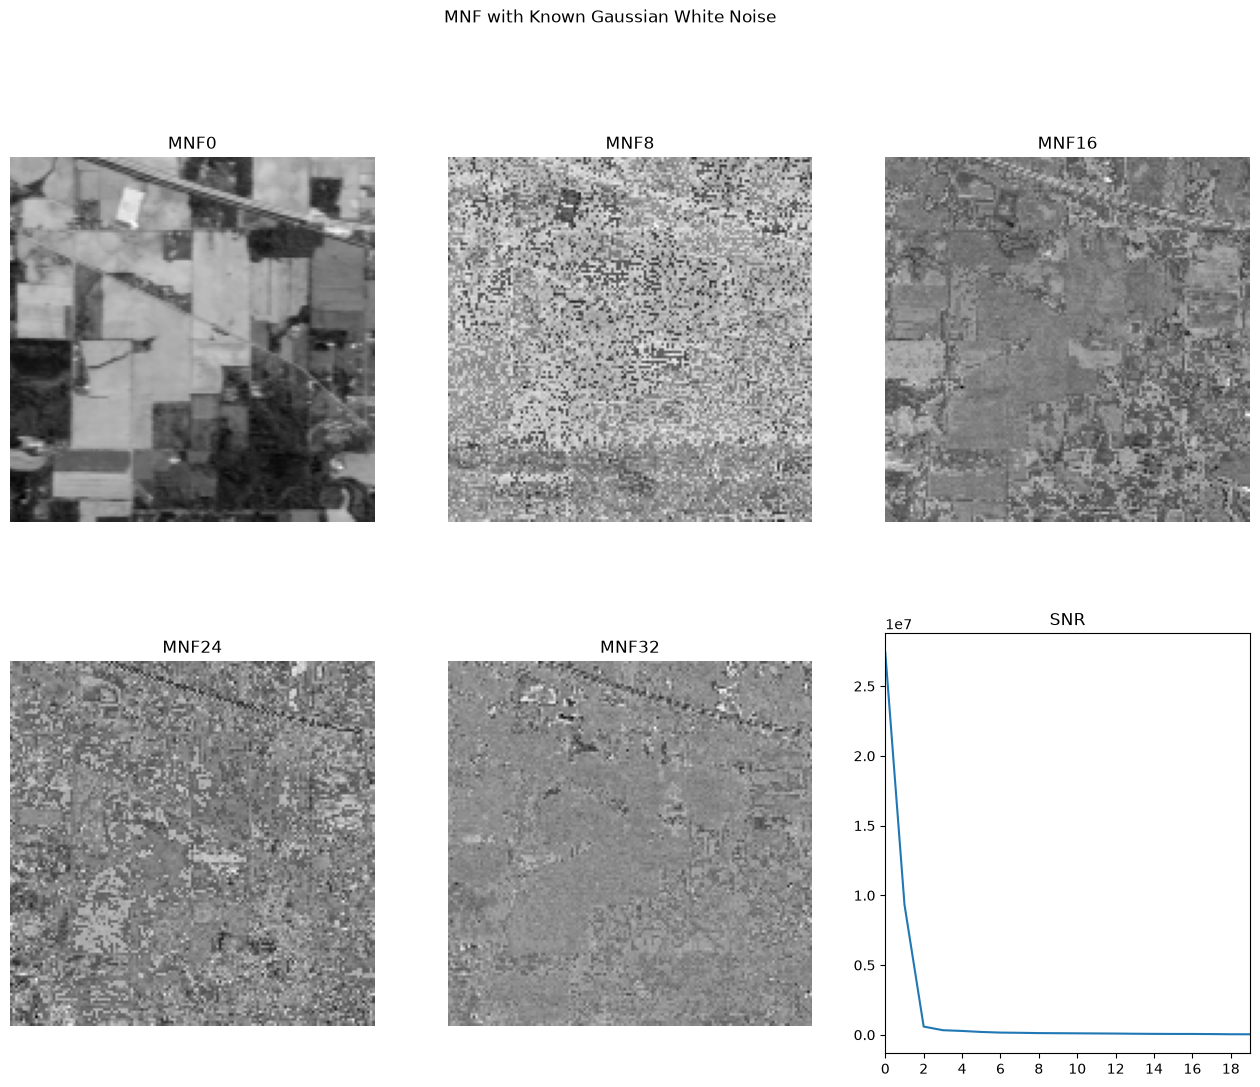

Original data shape: (145, 145, 200)
Reduced data shape: (145, 145, 200)


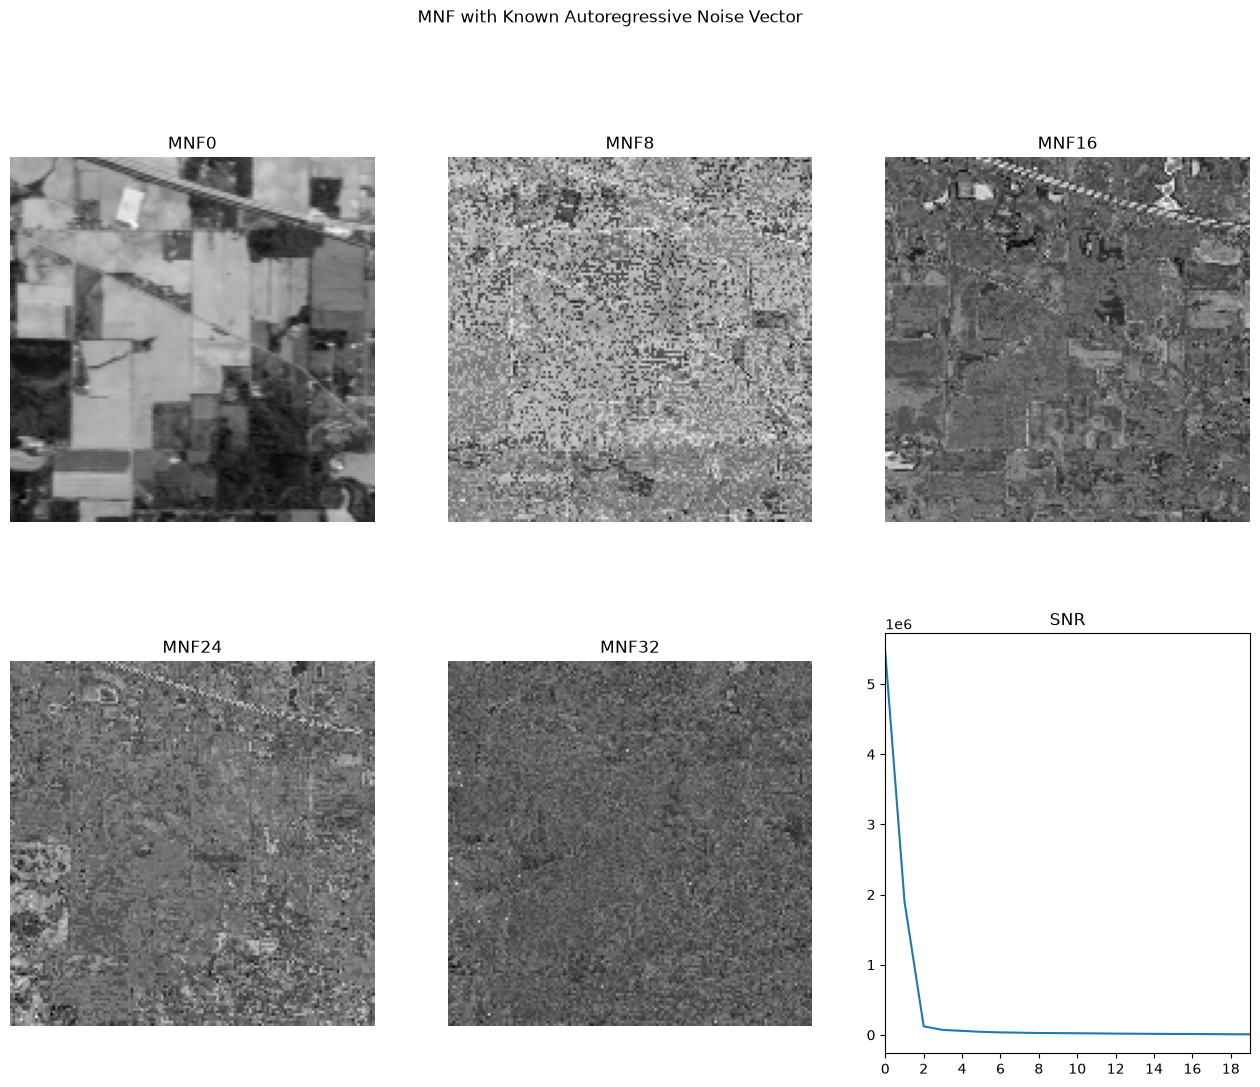

0

In [182]:
mnfKGWN, snrKGWN = MNFknown(inputDataGWN, gaussianWhiteNoise)
plotMNFImg(mnfKGWN, snrKGWN, "MNF with Known Gaussian White Noise")

mnfKANV, snrKANV = MNFknown(inputDataANV, autoregressive1NoiseVector)
plotMNFImg(mnfKANV, snrKANV, "MNF with Known Autoregressive Noise Vector")


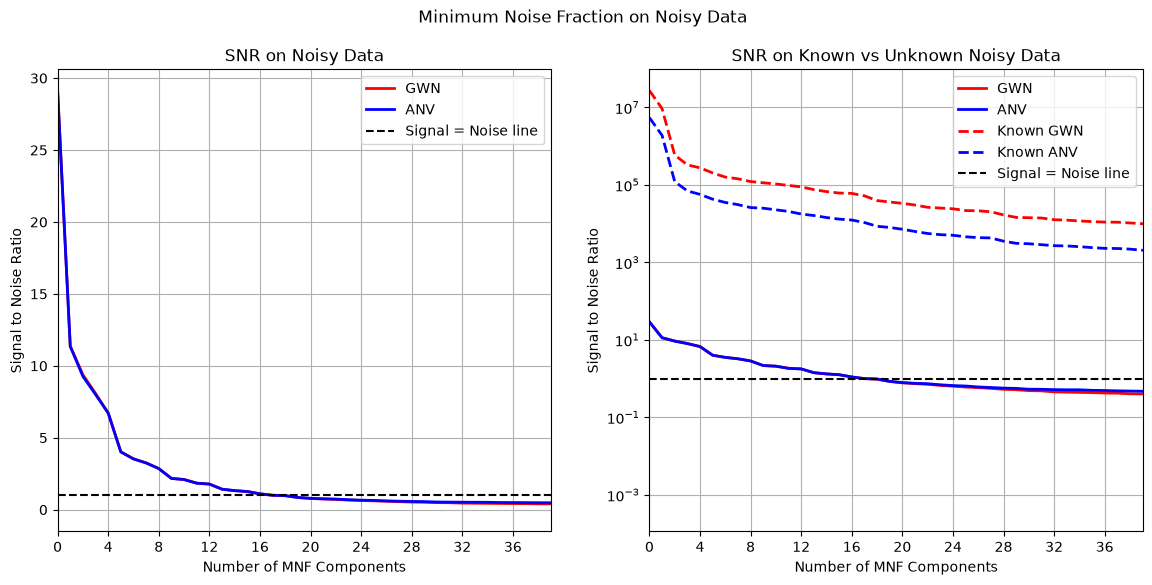

In [180]:
plt.figure(figsize=(14,6))
plt.suptitle("Minimum Noise Fraction on Noisy Data")
plt.subplot(121)
plt.plot(snrGWN, label="GWN", linewidth=2, color='r', linestyle='-')
plt.plot(snrANV, label="ANV", linewidth=2, color='b', linestyle='-')

plt.xlabel("Number of MNF Components")
plt.ylabel("Signal to Noise Ratio")
plt.hlines(1, xmin=0,xmax=200, linestyles='--', color='k', label='Signal = Noise line')
plt.xlim(0,39)
#plt.ylim(0,1)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()
plt.grid(True)
plt.title('SNR on Noisy Data')

plt.subplot(122)
plt.semilogy(snrGWN, label="GWN", linewidth=2, color='r', linestyle='-')
plt.semilogy(snrANV, label="ANV", linewidth=2, color='b', linestyle='-')

plt.semilogy(snrKGWN, label="Known GWN", linewidth=2, color='r', linestyle='--')
plt.semilogy(snrKANV, label="Known ANV", linewidth=2, color='b', linestyle='--')

plt.xlabel("Number of MNF Components")
plt.ylabel("Signal to Noise Ratio")
plt.hlines(1, xmin=0,xmax=200, linestyles='--', color='k', label='Signal = Noise line')
plt.xlim(0,39)
#plt.ylim(0,1)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()
plt.grid(True)
plt.title('SNR on Known vs Unknown Noisy Data')

plt.show()